# Optimal Execution and Market Making

Vu-Minh D. Hoang

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import datetime as dt
import pandas as pd
import seaborn as sns
 
from download_binance_data import get_klines, get_tick_data

# I. Optimal split of orders across liquidity pools

### Projection Simplex

The Euclidean projection finds a vector $w^*$ that minimizes the $L_2$ distance to $v$:$$\min_{w \in \mathbb{R}^n} \frac{1}{2} \Vert{} w - v \Vert{}_2^2 \quad \text{subject to} \quad \sum_{i=1}^n w_i = z \quad \text{and} \quad w_i \ge 0, \;\forall i$$

$$\mathcal{L}(w, \theta, \lambda) = \frac{1}{2} \sum_{i=1}^n (w_i - v_i)^2 + \theta \left( \sum_{i=1}^n w_i - z \right) - \sum_{i=1}^n \lambda_i w_i$$

where $\theta \in \mathbb{R}$ is the Lagrange multiplier for the equality constraint, and $\lambda_i \ge 0$ are the multipliers for the non-negativity constraints $w_i \ge 0$.

Karush-Kuhn-Tucker (KKT) Conditions:

- Stationarity: $\frac{\partial \mathcal{L}}{\partial w_i} = w_i - v_i + \theta - \lambda_i = 0 \implies w_i = v_i - \theta + \lambda_i$
- Primal Feasibility: $\sum_{i=1}^n w_i = z \quad \text{and} \quad w_i \ge 0, \; \forall i$
- Dual Feasibility: $\lambda_i \ge 0, \; \forall i$
- Complementary Slackness: $\lambda_i w_i = 0, \; \forall i$

From complementary slackness and dual feasibility:
- If $w_i > 0$, then $\lambda_i = 0 \implies w_i = v_i - \theta$.
- If $w_i = 0$, then $\lambda_i = \theta - v_i \ge 0 \implies v_i - \theta \le 0$.

Combining these yields the solution: $w_i^* = \max(v_i - \theta, 0) = (v_i - \theta)^+$

The parameter $\theta$ must satisfy the equality constraint:$\sum_{i=1}^n w_i^* = \sum_{i=1}^n\max(v_i - \theta, 0) = z$. Let $u$ be the vector $v$ sorted in descending order: $u_1 \ge u_2 \ge \dots \ge u_n$

Because $u$ is ordered from largest to smallest, the positive outputs will naturally fall in the first $\rho$ positions, while positions $\rho+1$ through $n$ will all be set to $0$:$$w_i^* =  \begin{cases}  u_i - \theta & \text{for } i \le \rho \quad (\text{since } u_i - \theta > 0) \\  0 & \text{for } i > \rho \quad (\text{since } u_i - \theta \le 0)  \end{cases}$$

Summing over the first $\rho$ terms:$\sum_{i=1}^n w_i^* = \sum_{i=1}^{\rho} (u_i - \theta) = z$. Expanding and solving for $\theta$:$\sum_{i=1}^{\rho} u_i - \rho \cdot \theta = z \implies \theta = \frac{\sum_{i=1}^{\rho} u_i - z}{\rho}$

In [2]:
def projection_simplexe(v, z=1):
    n = len(v)
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u) - z
    rho = np.nonzero(u * np.arange(1, n+1) > cssv)[0][-1]
    theta = cssv[rho] / (rho + 1.0)
    w = np.maximum(v - theta, 0)
    return w

## Stochastic Approximation

### 1. Setup

* $V > 0$: random volume we need to execute over the period.
* $S > 0$: the reference (lit-market) price.
* For each dark pool $i = 1, \dots, N$: a discount factor $\theta_i \in (0, 1)$ (we trade there at price $\theta_i S < S$), a routed fraction $r_i \in [0, 1]$ of $V$, and an available (random) capacity $D_i \ge 0$ at that price.
* The unfilled remainder goes to the lit market at price $S$.

Since a dark pool can never fill more than it has capacity for, the quantity actually executed in pool $i$ is $\min(r_i V, D_i)$ — either the whole slice we sent, or the pool's capacity, whichever is smaller.

---

### 2. The cost formula 

$$
C = \underbrace{S \sum_{i=1}^{N} \theta_i \min(r_i V, D_i)}_{\text{filled in dark pools}} + \underbrace{S \left( V - \sum_{i=1}^{N} \min(r_i V, D_i) \right)}_{\text{residual on primary market}} = SV - S \sum_{i=1}^N \rho_i \min(r_i V, D_i), \quad \rho_i := 1 - \theta_i \in (0, 1)
$$

The first term doesn't depend on $r$, so minimizing $\mathbb{E}[C]$ over $r = (r_i)_{1\le i\le N}$ is equivalent to $$r^* \in\argmax_{r \in \mathcal{P}_N} \sum_{i=1}^{N} \rho_i \, \mathbb{E}[\min(r_i V, D_i)] =: \argmax_{r \in \mathcal{P}_N} \sum_{i=1}^{N} \varphi_i(r_i)=: \argmax_{r \in \mathcal{P}_N} \Phi(r), \quad \mathcal{P}_N = \left\{ r \in \mathbb{R}_+^N : \sum_{i=1}^N r_i = 1 \right\}.$$

---

### 3. Optimal solution

Introducing the affine hyperplane spanned by $\mathcal{P}_N $ i.e $\mathcal{H}_N = \left\{ r \in \mathbb{R}^N : \sum_{i=1}^N r_i = 1 \right\}$

We aim at solving the following maximization problem $\argmax_{r \in \mathcal{H}_N} \Phi(r),$ which yields: 

$$L(r, \lambda) = \Phi(r) - \lambda \left( \sum_{i=1}^N r_i - 1 \right)$$


Stationarity gives, for every $i$:

$$
\frac{\partial L}{\partial r_i} = \varphi'_i(r_i) - \lambda = 0 \implies \varphi'_i(r^*_i) = \lambda \quad \forall i.
$$

Since all $N$ marginal values equal the *same* $\lambda$, they also equal their own average:

$$
\varphi'_i(r^*_i) = \frac{1}{N} \sum_{j=1}^{N} \varphi'_j(r^*_j), \quad \forall i.
$$

Under some appropriate assumptions (see Proposition 3.1's $(\mathcal{C})$ of "Optimal split of orders across liquidity pools: a
stochastic algorithm approach"), then $$\argmax_{r \in \mathcal{H}_N} \Phi(r)= \argmax_{r \in \mathcal{P}_N} \Phi(r).$$

---

### 4. Computing  $\varphi'_i$

Differentiating pointwise yields:

$$
\frac{d}{du} \min(uV, D_i) = V \cdot \mathbb{1}_{\{uV < D_i\}}
$$

Differentiating under the expectation $\varphi'_i(u) = \rho_i \mathbb{E}\left[V \mathbb{1}_{\{uV < D_i\}}\right]$ is justified under three assumptions:

1. **Continuous Distribution ($\mathbb{P}(uV = D_i) = 0$):** Either $V$ or $D_i$ is continuously distributed, so the non-differentiable set $\{uV = D_i\}$ has measure zero for almost every $u$.
2. **Dominating Envelope:** The derivative is bounded almost surely by $V$ (since $|V \cdot \mathbb{1}_{\{uV < D_i\}}| \le V$), which is independent of $u$.
3. **Finite Expectation:** $V$ is integrable ($\mathbb{E}[|V|] < \infty$).

Hence:

$$
\varphi'_i(u) = \rho_i \mathbb{E}\left[V \mathbb{1}_{\{uV < D_i\}}\right].
$$

The optimality condition becomes: for every $i$,

$$
\rho_i \mathbb{E}\left[ V \mathbb{1}_{\{r^*_i V < D_i\}} \right] = \frac{1}{N} \sum_{j=1}^{N} \rho_j \mathbb{E}\left[ V \mathbb{1}_{\{r^*_j V < D_j\}} \right]
$$

or, moving everything inside a single expectation,

$$
\mathbb{E}\left[ \underbrace{V \left( \rho_i \mathbb{1}_{\{r^*_i V < D_i\}} - \frac{1}{N} \sum_{j=1}^N \rho_j \mathbb{1}_{\{r^*_j V < D_j\}} \right)}_{=: H_i(r^*, Y)} \right] = 0, \quad \forall i=1,..., N, \text{with } Y = (V, D_1, \dots, D_N).
$$

**This is the crucial reformulation.** We've turned "maximize an expectation" into "find the zero of an expectation", so
$r^*$ is the point where: $$h(r) := \mathbb{E}[H(r, Y)] = 0 \iff \begin{bmatrix} \mathbb{E}[H_1(r, Y)] \\ \mathbb{E}[H_2(r, Y)] \\ \vdots \\ \mathbb{E}[H_N(r, Y)] \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \\ \vdots \\ 0 \end{bmatrix}$$


### 5.Robbins–Monro algorithm

To find $r^*$ analytically we need to know the joint distribution of $(V, D_1, \dots, D_N)$ — which we don't. But at each trading period $k$, we do observe a realization $Y^{(k+1)} = (V^{(k+1)}, D_1^{(k+1)}, \dots, D_N^{(k+1)})$ of the sequence $(Y^{(k)})_{k \ge 1} := (V^{(k)}, D_1^{(k)}, \dots, D_N^{(k)})_{k \ge 1}$. We will make stationary assumptions on the sequence:
* either $(Y^{(k)})_{k \ge 1}$ is i.i.d.,
* or $(Y^{(k)})_{k \ge 1}$ is ergodic with some rate (e.g. $\alpha$-mixing).

When updating $r^{(k+1)}$, the entire vector is updated simultaneously at step $k$:$$r^{(k+1)} = \Pi_{\mathcal{P}_N} \left( r^{(k)} + \gamma_k H(r^{(k)}, Y^{(k+1)}) \right), \quad r^{(0)}\in \mathcal{P}_N $$

with a step size $\gamma_k \to 0$ satisfying $\sum_{k\ge 1} \gamma_k = \infty$ and $\sum_{k\ge 1} \gamma_k^2 < \infty$ — the canonical choice being $\gamma_k = c/k$ for some $c>0$ that guarantees convergence. $\Pi_{\mathcal{P}_N}$ is the projection operator that maps any vector onto the probability simplex $\mathcal{P}_N = \{ r \in \mathbb{R}_+^N : \sum_{i=1}^N r_i = 1 \}$, ensuring that the updated allocation fractions remain valid probabilities that sum to 1.

It follows that $r^{(k)} \xrightarrow{\mathbb{P}-a.s} r^*$ as $k\to\infty$.

## Pseudo-Real Data Generation

Because dark pool capacities $D_i$ are unobservable in historical tick data, market liquidity is simulated using real lit-market trading volumes $V$ (e.g., BNP Paribas stock) alongside $N$ volume-correlated assets $S_i$ over an 11-day period.

### 1. Data Model Formulation

For each dark pool $i \in \{1, \dots, N\}$, the available capacity $D_i$ is constructed via the mixing function:

$$\forall 1 \le i \le N, \quad D_i := \beta_i \left( (1 - \alpha_i) V + \alpha_i S_i \frac{\mathbb{E}[V]}{\mathbb{E}[S_i]} \right)$$

* **$V$**: Target asset trading volume.
* **$S_i$**: Correlated asset trading volume.
* **$\alpha_i \in [0, 1]$**: Mixing parameter controlling the reliance on general market trends vs. pool-specific noise.
* **$\beta_i > 0$**: Scaling parameter dictating pool capacity relative to order size.

---

### 2. The Shortage Condition $\mathbb{E}\left[\sum_{i=1}^N D_i\right] < \mathbb{E}[V]$
The total average capacity across all $N$ dark pools combined is less than the total volume $V$ we need to execute.
This creates a liquidity-scarce environment defined by the condition:
$\sum_{i=1}^N \beta_i < 1 \implies \mathbb{E}\left[\sum_{i=1}^N D_i\right] < \mathbb{E}[V]$

#### Proof

By linearity of expectation:
   
   $$\mathbb{E}[D_i] = \beta_i \left( (1 - \alpha_i) \mathbb{E}[V] + \alpha_i \mathbb{E}[S_i] \frac{\mathbb{E}[V]}{\mathbb{E}[S_i]} \right) = \beta_i \mathbb{E}[V] (1 - \alpha_i + \alpha_i) = \beta_i \mathbb{E}[V]$$
 
Summing across all $N$ dark pools:
   
   $$\mathbb{E}\left[ \sum_{i=1}^N D_i \right] = \sum_{i=1}^N \mathbb{E}[D_i] = \left( \sum_{i=1}^N \beta_i \right) \mathbb{E}[V] < \mathbb{E}[V] \quad \blacksquare$$

This corresponds to the case that total dark pool capacity cannot fulfill order demand on average.

--- 

### 3. Oracle Benchmarking

An Oracle is a hypothetical trader who has "cheating" insider knowledge: before routing any volume, the Oracle already knows exact order volume $V^n$ and exact available capacity $D_i^n$ in every dark pool for period $n$.

Assuming that dark pool execution discounts are ordered from best to worst ($\rho_1 > \rho_2 > \dots > \rho_N$), the Oracle uses a greedy strategy:

- Fill Pool 1 completely to maximize cost reduction $\rho_1 D_1^n$.
- Fill Pool 2 completely for $\rho_2 D_2^n$.
- Keep going down the line until either:
  + Case 1 (Volume runs out at pool $i_0$): You run out of order volume $V^n$. The marginal pool $i_0$ receives only the remaining unfulfilled order amount: $\left(V^n - \sum_{i=1}^{i_0-1} D_i^n\right)$.
  + Case 2 (Dark pool capacities run out): All $N$ dark pools are completely exhausted ($\sum_{i=1}^N D_i^n < V^n$), capturing the maximum possible cost reduction $\sum_{i=1}^N \rho_i D_i^n$.

Cost reduction (CR) of the execution at time $n ≥ 1$

$$\mathrm{CR}^{oracle} := \begin{cases} \sum_{i=1}^{i_0-1} \rho_i D_i^n + \rho_{i_0} \left( V^n - \sum_{i=1}^{i_0-1} D_i^n \right), & \text{if } \sum_{i=1}^{i_0-1} D_i^n \le V^n < \sum_{i=1}^{i_0} D_i^n \\ \sum_{i=1}^N \rho_i D_i^n, & \text{if } \sum_{i=1}^N D_i^n < V^n. \end{cases}$$

Performance Benchmark (Oracle Ratio)

We evaluate algorithm efficiency by comparing its cost savings against the unbeatable Oracle strategy (perfect foresight). 

At each step $n \ge 1$, we compute :$ \frac{\mathrm{CR}^{\text{opti}}}{\mathrm{CR}^{\text{oracle}}}$. With $\mathrm{CR}^{\text{opti}}$ stands for the Cost Reduction achieved by the Optimal (Robbins–Monro) algorithm at step $n$. Formula for $\mathrm{CR}^{\text{opti}}$ is $\mathrm{CR}^{\text{opti}} = \sum_{i=1}^N \rho_i \min\left(r_{i, n}^* V^n, \, D_i^n\right)$, where $r_{i, n}^*$: The fraction of total volume $V^n$ allocated to dark pool $i$ at step $n$.

Because $V^n$ and $D_i^n$ introduce heavy per-period noise, we track performance using a running moving average expressed as a percentage.


## Experiment

In [3]:
candidate_assets = ["ETHUSDT", "BNBUSDT", "SOLUSDT", "XRPUSDT", "ADAUSDT",
                     "DOGEUSDT", "AVAXUSDT", "LINKUSDT", "DOTUSDT", "LTCUSDT"]
traded_asset = "BTCUSDT"
T = 1
start_date, end_date = "2024-01-01", "2024-01-30"

# pull the traded asset's volume
df_traded = get_klines(traded_asset, f"{T}m", start_date, end_date, market="spot")
traded_volume = df_traded["Volume"]

# pull every candidate's volume
dico_volumes_candidates = {}
for sym in candidate_assets:
    df = get_klines(sym, f"{T}m", start_date, end_date, market="spot")
    dico_volumes_candidates[sym] = df["Volume"]

idx = traded_volume.index
for v in dico_volumes_candidates.values():
    idx = idx.intersection(v.index)

traded_volume_aligned = traded_volume.loc[idx]

correlations = {
    sym: traded_volume_aligned.corr(v.loc[idx])
    for sym, v in dico_volumes_candidates.items()
}
corr_series = pd.Series(correlations).sort_values(ascending=False)
print(corr_series)

top5 = corr_series.head(5).index.tolist()
print(f"Top 5 most correlated to {traded_asset}:", top5)

assets = [traded_asset] + top5

ETHUSDT     0.669619
SOLUSDT     0.564814
ADAUSDT     0.543923
AVAXUSDT    0.517597
LTCUSDT     0.484768
XRPUSDT     0.481096
DOTUSDT     0.464549
BNBUSDT     0.403263
LINKUSDT    0.395663
DOGEUSDT    0.357074
dtype: float64
Top 5 most correlated to BTCUSDT: ['ETHUSDT', 'SOLUSDT', 'ADAUSDT', 'AVAXUSDT', 'LTCUSDT']


In [4]:
dico_prices, dico_volumes = {}, {}
for sym in assets:
    df = get_klines(sym, f"{T}m", start_date, end_date, market="spot")
    dico_prices[sym] = df["Close"]
    dico_volumes[sym] = df["Volume"]

idx = None
for s in dico_prices.values():
    idx = s.index if idx is None else idx.intersection(s.index)
dico_prices  = {k: v.loc[idx] for k, v in dico_prices.items()}
dico_volumes = {k: v.loc[idx] for k, v in dico_volumes.items()}

In [5]:
class DarkPool: 

    def __init__(self, 
                 traded_asset: str, 
                 assets: list[str],
                 alpha: np.array,
                 beta: np.array,
                 rho: np.array) -> None:
        
        self.beta = beta
        self.alpha = alpha
        self.rho = rho
        self.traded_asset = traded_asset

        reference_assets = assets.copy()
        reference_assets.remove(traded_asset)
        self.reference_assets = reference_assets
        self.dico_darkpools = None
        self.dico_prices = None       
        self.dico_volumes = None     


    def create_darkpools(self, 
                         dico_prices: dict,
                         dico_volumes: dict) -> None:
        
        self.dico_prices = dico_prices
        self.dico_volumes = dico_volumes

        dico_darkpools = {}

        traded_volume = dico_volumes[self.traded_asset]
        mean_traded_volume = traded_volume.mean()

        for (i, asset) in enumerate(self.reference_assets):
            alpha = self.alpha[i]
            beta = self.beta[i]

            volume_asset = dico_volumes[asset]         
            mean_volume_asset = volume_asset.mean()

            darkpool = beta * ((1 - alpha) * traded_volume
                                + alpha * volume_asset * mean_traded_volume / mean_volume_asset)
            dico_darkpools[asset] = darkpool

        self.dico_darkpools = dico_darkpools
        

    # allocation by stochastic approximation
    def compute_stochastic_allocation(self,
                                      r0: np.array,
                                      c = 0.01) -> tuple[pd.DataFrame, np.array]:

        r = projection_simplexe(np.asarray(r0, dtype=float).copy())

        dates = self.dico_volumes[self.traded_asset].index
        traded_volume = self.dico_volumes[self.traded_asset]
        allocation = np.zeros((len(dates), len(self.reference_assets)))
        
        n = 1
        gamma = c/n

        for (j, date) in enumerate(dates):

            H = np.zeros(len(self.reference_assets))

            for (i, asset) in enumerate(self.reference_assets):
                
                if r[i]*traded_volume[date] < self.dico_darkpools[asset][date]:
                    H[i] = self.rho[i]

            H -= np.mean(H)
            H *= traded_volume[date]

            r = projection_simplexe(r + gamma * H)

            n += 1
            gamma = c/n
            
            allocation[j] = r
        
        return dates, allocation
    
    # allocation look-ahead in benchmark
    def compute_oracle_allocation(self):
        
        dates = self.dico_volumes[self.traded_asset].index
        traded_volume = np.array(self.dico_volumes[self.traded_asset])

        allocation = np.zeros((len(dates), len(self.reference_assets)))

        indices_tries = sorted(range(len(self.rho)), key=lambda i: self.rho[i], reverse=True)
        remaining_quantity_to_allocate = np.ones(len(dates))
        for i in indices_tries:

            allocation[:, i] = np.minimum(remaining_quantity_to_allocate, np.array(self.dico_darkpools[self.reference_assets[i]])/traded_volume)
            remaining_quantity_to_allocate -= allocation[:, i]
        
        return dates, allocation

    # calculation of trade costs
    def compute_cost(self, 
                     allocation: np.array) -> np.array:
    
        price_asset = self.dico_prices[self.traded_asset].astype(float)
        traded_volume = np.array(self.dico_volumes[self.traded_asset]).astype(float)
        cost = traded_volume.copy()

        for (i, asset) in enumerate(self.reference_assets):
            
            cost -= self.rho[i]*np.minimum(allocation[:, i]*traded_volume, np.array(self.dico_darkpools[asset]).astype(float))
            
        cost *= price_asset
        
        return cost

In [6]:
from download_binance_data import BASE_URL, _fetch_zip_csv, _BOOKTICKER_COLUMNS
 
 
def _daterange(start_date: str, end_date: str):
    d0 = dt.date.fromisoformat(start_date)
    d1 = dt.date.fromisoformat(end_date)
    d = d0
    while d <= d1:
        yield d.isoformat()
        d += dt.timedelta(days=1)
 
 
def calibrate_half_spread(asset: str, start_date: str, end_date: str,
                           market: str = "futures/um") -> float:
    total_rel_spread = 0.0
    count = 0
 
    for date in _daterange(start_date, end_date):
        url = f"{BASE_URL}/data/{market}/daily/bookTicker/{asset}/{asset}-bookTicker-{date}.zip"
        df = _fetch_zip_csv(url, _BOOKTICKER_COLUMNS)
 
        if df.empty:
            continue
 
        bid = df["BidPrice"].astype(float)
        ask = df["AskPrice"].astype(float)
        mid = (bid + ask) / 2
        rel_spread = (ask - bid) / (2 * mid)
 
        total_rel_spread += rel_spread.sum()
        count += len(rel_spread)
 
        del df, bid, ask, mid, rel_spread
 
    if count == 0:
        raise ValueError(f"No bookTicker data found for {asset} between {start_date} and {end_date}")
 
    return total_rel_spread / count
 
 
def calibrate_rho(traded_asset: str,
                   reference_assets: list,
                   start_date: str,
                   end_date: str,
                   market: str = "futures/um") -> np.ndarray:
    traded_half_spread = calibrate_half_spread(traded_asset, start_date, end_date, market)
    print(f"{traded_asset} half-spread (anchor level): {traded_half_spread:.6f}")
 
    reference_half_spreads = np.array([
        calibrate_half_spread(a, start_date, end_date, market) for a in reference_assets
    ])
    for a, s in zip(reference_assets, reference_half_spreads):
        print(f"{a}: half-spread = {s:.6f}")
 
    relative_competitiveness = reference_half_spreads.mean() / reference_half_spreads
    rho = traded_half_spread * relative_competitiveness
 
    print("\nCalibrated rho (anchored to traded asset, scaled by reference liquidity):")
    for a, r in zip(reference_assets, rho):
        print(f"  {a}: rho = {r:.6f}")
 
    return rho


reference_assets = [a for a in assets if a != traded_asset]
 
calib_start_date = "2024-01-01"
calib_end_date = "2024-01-05"
 
rho = calibrate_rho(traded_asset, reference_assets, calib_start_date, calib_end_date)

BTCUSDT half-spread (anchor level): 0.000002
ETHUSDT: half-spread = 0.000003
SOLUSDT: half-spread = 0.000019
ADAUSDT: half-spread = 0.000090
AVAXUSDT: half-spread = 0.000037
LTCUSDT: half-spread = 0.000077

Calibrated rho (anchored to traded asset, scaled by reference liquidity):
  ETHUSDT: rho = 0.000030
  SOLUSDT: rho = 0.000005
  ADAUSDT: rho = 0.000001
  AVAXUSDT: rho = 0.000003
  LTCUSDT: rho = 0.000001


In [7]:
print("\nCalibrated rho:", rho)


Calibrated rho: [3.04012697e-05 5.24994736e-06 1.07702555e-06 2.66073850e-06
 1.27320781e-06]


In [8]:
def calibrate_alpha(traded_asset: str,
                     reference_assets: list,
                     dico_volumes: dict,
                     mapping: str = "one_minus_r",
                     clip_bounds: tuple = (0.05, 0.95)) -> np.ndarray:
    traded_volume = dico_volumes[traded_asset]
    R = np.array([abs(traded_volume.corr(dico_volumes[a])) for a in reference_assets])

    if mapping == "one_minus_r":
        alpha = 1 - R
    elif mapping == "r":
        alpha = R
    else:
        raise ValueError("mapping must be 'one_minus_r' or 'r'")

    alpha = np.clip(alpha, *clip_bounds)

    for a, r, al in zip(reference_assets, R, alpha):
        print(f"{a}: R = {r:.4f}  ->  alpha = {al:.4f}")

    return alpha

def calibrate_beta(traded_asset, reference_assets, dico_prices, dico_volumes, target_total_beta=0.12):
    traded_notional = (dico_volumes[traded_asset] * dico_prices[traded_asset]).mean()
    relative_volume = np.array([
        (dico_volumes[a] * dico_prices[a]).mean() / traded_notional
        for a in reference_assets
    ])
    beta = target_total_beta * relative_volume / relative_volume.sum()

    for a, b in zip(reference_assets, beta):
        print(f"{a}: beta = {b:.4f}")
    print(f"sum(beta) = {beta.sum():.4f}")
    return beta

In [9]:
reference_assets = [a for a in assets if a != traded_asset]

alpha = calibrate_alpha(traded_asset, reference_assets, dico_volumes, mapping="one_minus_r")
beta  = calibrate_beta(traded_asset, reference_assets, dico_prices, dico_volumes, target_total_beta=0.25)

darkpool = DarkPool(traded_asset, assets, alpha, beta, rho)  # real rho, no rescaling
darkpool.create_darkpools(dico_prices, dico_volumes)

ETHUSDT: R = 0.6696  ->  alpha = 0.3304
SOLUSDT: R = 0.5648  ->  alpha = 0.4352
ADAUSDT: R = 0.5439  ->  alpha = 0.4561
AVAXUSDT: R = 0.5176  ->  alpha = 0.4824
LTCUSDT: R = 0.4848  ->  alpha = 0.5152
ETHUSDT: beta = 0.1393
SOLUSDT: beta = 0.0808
ADAUSDT: beta = 0.0095
AVAXUSDT: beta = 0.0147
LTCUSDT: beta = 0.0058
sum(beta) = 0.2500


In [10]:
for a in darkpool.reference_assets:
    D_i = darkpool.dico_darkpools[a]
    ratio = (D_i / dico_volumes[traded_asset]).median()
    print(f"{a}: median(D_i / V) = {ratio:.4f}")

ETHUSDT: median(D_i / V) = 0.1378
SOLUSDT: median(D_i / V) = 0.0815
ADAUSDT: median(D_i / V) = 0.0087
AVAXUSDT: median(D_i / V) = 0.0139
LTCUSDT: median(D_i / V) = 0.0049


In [11]:
from check_condition_c import check_condition_c

result = check_condition_c(darkpool)

Proposition 3.1 — Condition (C) / (C<) Check
N = 5 pools,  u_bound = 1/(N-1) = 0.2500
ρ = [3.04012697e-05 5.24994736e-06 1.07702555e-06 2.66073850e-06
 1.27320781e-06]
Number of time periods: 43200
-----------------------------------------------------------------
  Pool 0 (ETHUSDT):
    ρ0 = 0.0000
    φ'0(0)              = 0.000960
    φ'0(1/(N-1)=0.2500) = 0.000024

  Pool 1 (SOLUSDT):
    ρ1 = 0.0000
    φ'1(0)              = 0.000166
    φ'1(1/(N-1)=0.2500) = 0.000002

  Pool 2 (ADAUSDT):
    ρ2 = 0.0000
    φ'2(0)              = 0.000034
    φ'2(1/(N-1)=0.2500) = 0.000000

  Pool 3 (AVAXUSDT):
    ρ3 = 0.0000
    φ'3(0)              = 0.000084
    φ'3(1/(N-1)=0.2500) = 0.000000

  Pool 4 (LTCUSDT):
    ρ4 = 0.0000
    φ'4(0)              = 0.000040
    φ'4(1/(N-1)=0.2500) = 0.000000

-----------------------------------------------------------------
  LHS = min_i φ'i(0)         = 0.00003399   (pool 2)
  RHS = max_i φ'i(1/(N-1))   = 0.00002376   (pool 0)
  Gap = LHS - RHS           

If $(C_<)$ holds: "Condition $(C_<)$ is verified empirically, confirming that the maximizer lies in the interior of the simplex and all pools receive positive allocation.

In [12]:
r0 = np.ones(5) / 5
dates, allocation_sto = darkpool.compute_stochastic_allocation(r0, c= 50000)
dates, allocation_oracle = darkpool.compute_oracle_allocation()

In [13]:
cost_oracle = darkpool.compute_cost(allocation_oracle)
cost_sto = darkpool.compute_cost(allocation_sto)

no_darkpool_allocation = np.zeros(allocation_oracle.shape)
cost_no_darkpool = darkpool.compute_cost(no_darkpool_allocation)

In [14]:
CR_opti = (cost_no_darkpool-cost_sto)
CR_oracle = (cost_no_darkpool-cost_oracle)

performance = CR_opti/CR_oracle
performance

DateTime
2024-01-01 00:00:00    1.0
2024-01-01 00:01:00    1.0
2024-01-01 00:02:00    1.0
2024-01-01 00:03:00    1.0
2024-01-01 00:04:00    1.0
                      ... 
2024-01-30 23:55:00    1.0
2024-01-30 23:56:00    1.0
2024-01-30 23:57:00    1.0
2024-01-30 23:58:00    1.0
2024-01-30 23:59:00    1.0
Name: Close, Length: 43200, dtype: float64

In [15]:
print((CR_oracle == 0).sum(), "zero-CR_oracle periods")
performance = performance.replace([np.inf, -np.inf], np.nan) 

print("max performance:", performance.max())  

0 zero-CR_oracle periods
max performance: 1.0


In [16]:
nb_data_points_per_day = int(24*60/T) #(minutes in a day) / (minutes per bar) = number of T-minute bars per day.

# moving average calculation
window_size = 200
y_ma = np.convolve(np.array(performance.values), np.ones(window_size)/window_size, mode='valid')

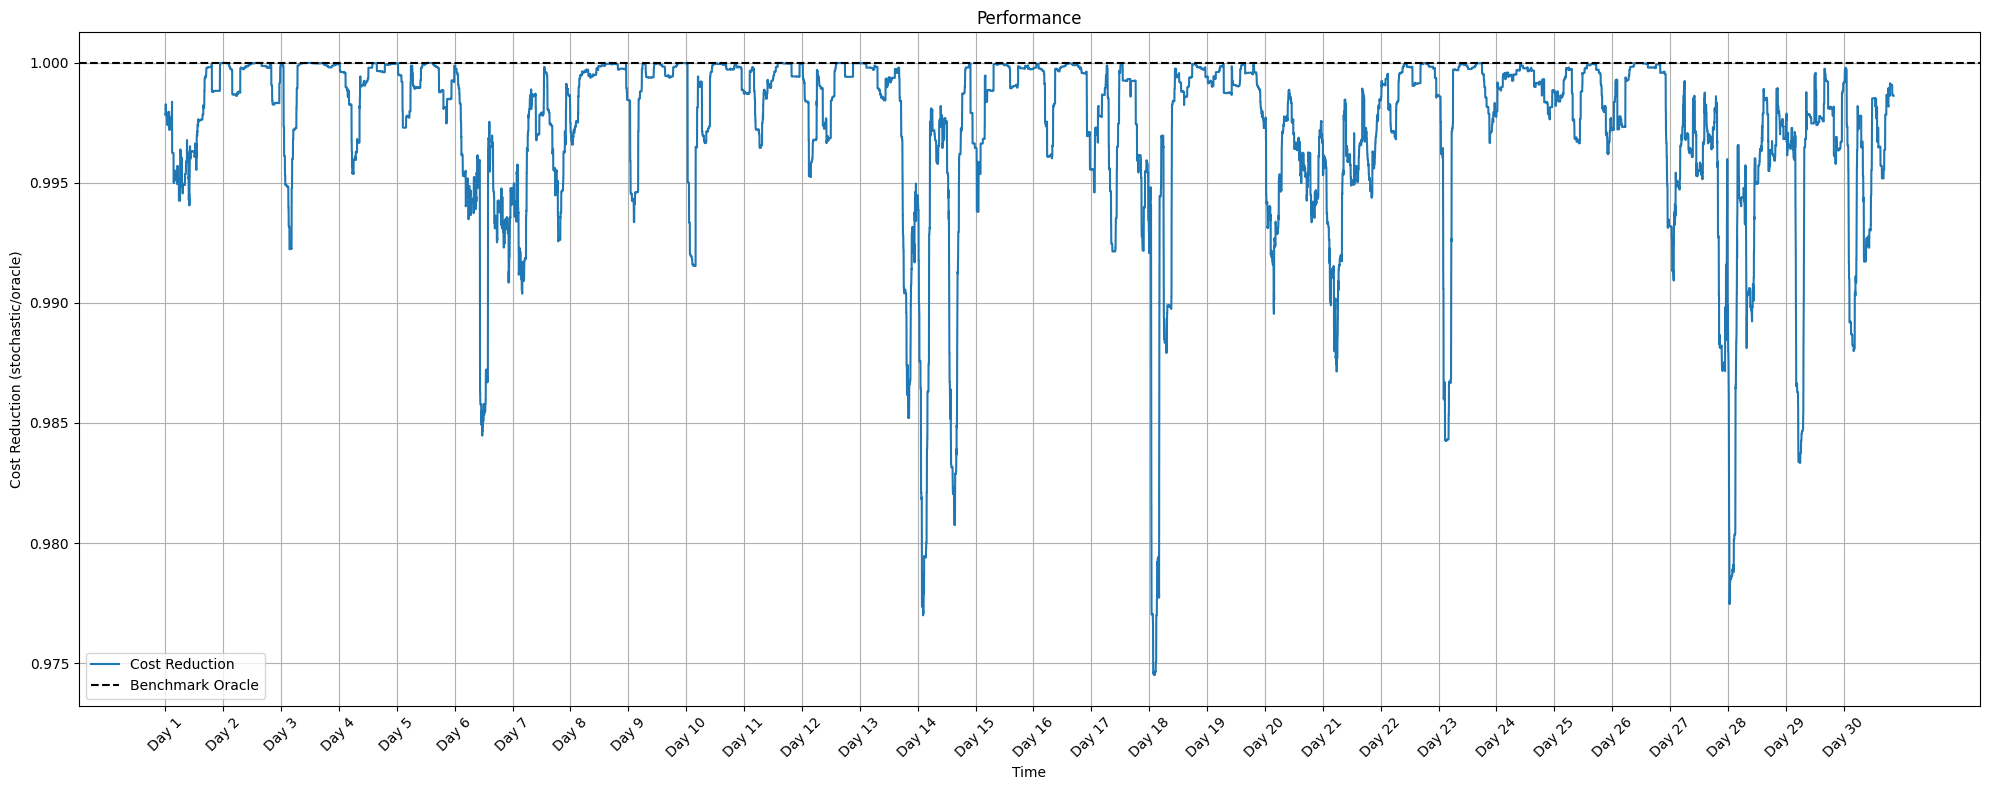

In [17]:
plt.figure(figsize=(20, 8))
plt.plot(y_ma, linestyle="-", label="Cost Reduction")

plt.axhline(
    y=1.00, color="black", linestyle="--", linewidth=1.5, label="Benchmark Oracle"
)

plt.xlabel("Time")
plt.ylabel("Cost Reduction (stochastic/oracle)")
plt.title("Performance")

indices = np.arange(0, len(y_ma), nb_data_points_per_day)
jours = [f"Day {i//nb_data_points_per_day + 1}" for i in indices]
plt.xticks(indices, jours, rotation=45)

plt.grid(True)
plt.legend()  
plt.tight_layout()
plt.show()

Number of lines actually plotted: 5


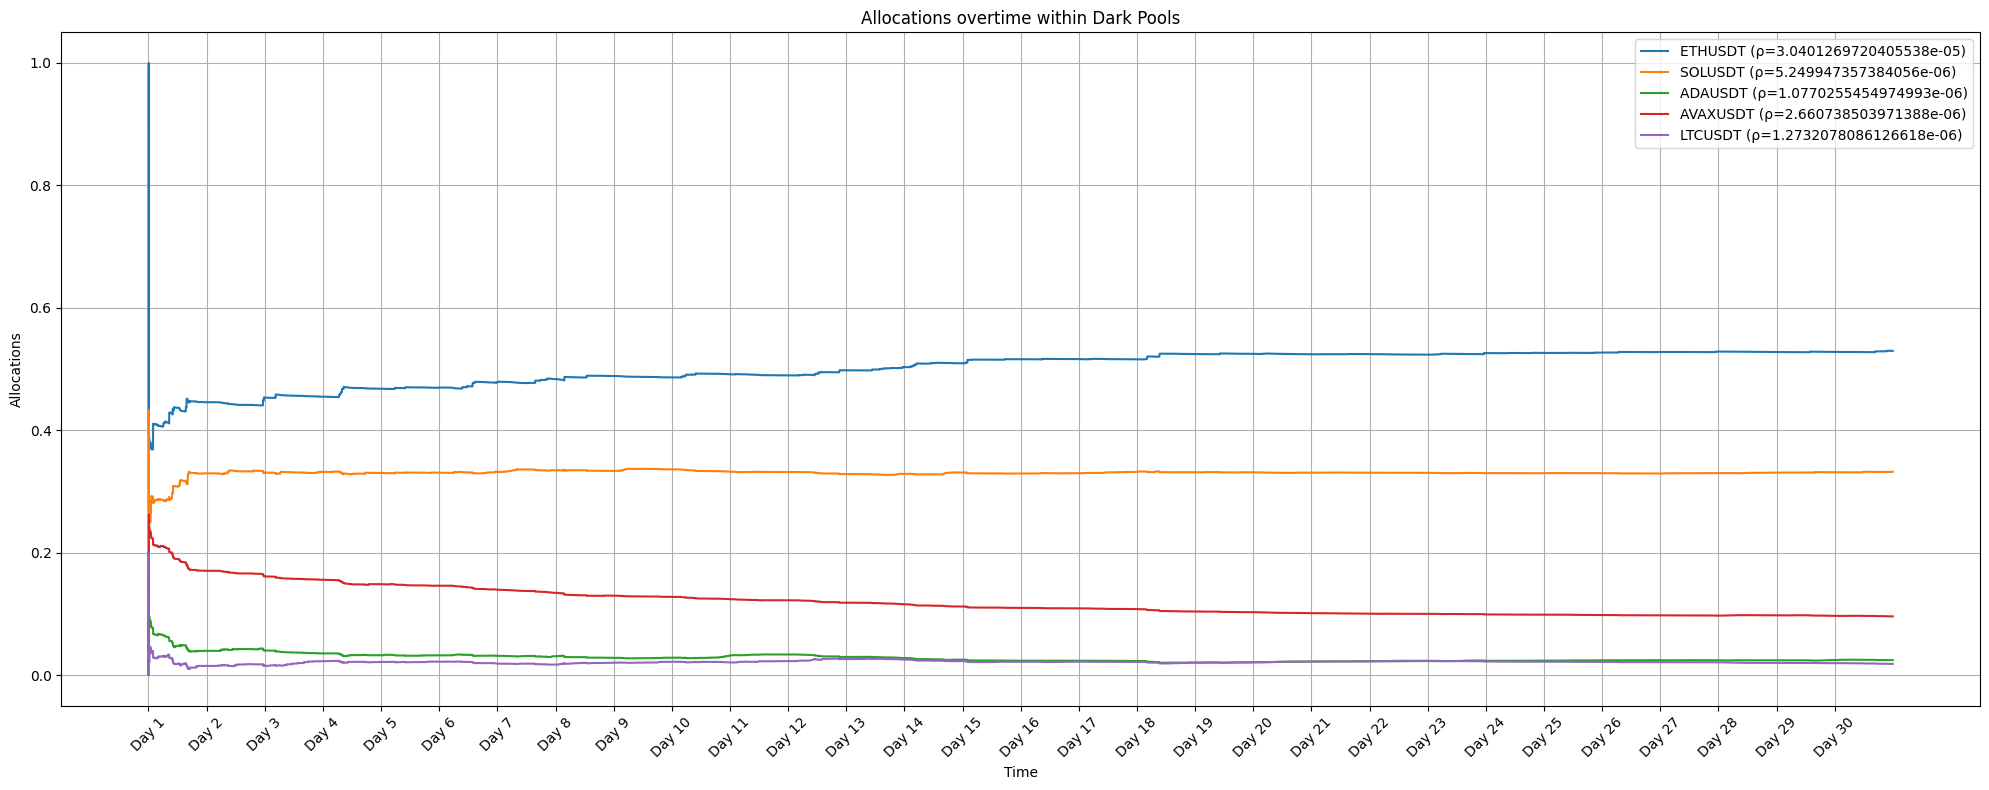

In [18]:
plt.figure(figsize=(20, 8))

for i, asset in enumerate(darkpool.reference_assets):
    plt.plot(allocation_sto[:, i], linestyle='-', label=f'{asset} (ρ={darkpool.rho[i]})')
 
plt.xlabel('Time')
plt.ylabel('Allocations')
plt.title('Allocations overtime within Dark Pools')
 
indices = np.arange(0, len(performance.values), nb_data_points_per_day)
jours = [f'Day {i//nb_data_points_per_day + 1}' for i in indices]
plt.xticks(indices, jours, rotation=45)
 
plt.legend()
plt.grid(True)
plt.tight_layout()
print("Number of lines actually plotted:", len(plt.gca().lines)) 
plt.show()

In [19]:
print("Final stochastic allocation:")
for i, a in enumerate(darkpool.reference_assets):
    print(f"  {a}: r = {allocation_sto[-1, i]:.6f}")

print(f"Sum of final stochastic allocation: {allocation_sto[-1].sum():.6f}")
print(f"Number of reference assets: {len(darkpool.reference_assets)}")

Final stochastic allocation:
  ETHUSDT: r = 0.529598
  SOLUSDT: r = 0.332078
  ADAUSDT: r = 0.024409
  AVAXUSDT: r = 0.095796
  LTCUSDT: r = 0.018119
Sum of final stochastic allocation: 1.000000
Number of reference assets: 5


In [20]:
diffs = np.linalg.norm(np.diff(allocation_sto, axis=0), axis=1)
n_nonzero = (diffs > 1e-10).sum()
print(f"Nonzero-movement steps: {n_nonzero} / {len(diffs)}  ({100*n_nonzero/len(diffs):.3f}%)")

nonzero_idx = np.where(diffs > 1e-10)[0]
print("First 10 trigger step indices:", nonzero_idx[:10])
print("Largest 5 jumps:", np.sort(diffs)[-5:])

Nonzero-movement steps: 4159 / 43199  (9.628%)
First 10 trigger step indices: [  5   6   7  11  23  52  60  70  73 112]
Largest 5 jumps: [0.04693995 0.09356595 0.34227343 0.61480351 0.89442719]


In [21]:
def phi_prime(u, V, D_i, rho_i):
    indicator = (u * V < D_i).astype(float)
    return rho_i * np.mean(V * indicator)

V = np.array(darkpool.dico_volumes[traded_asset], dtype=float)
r_final = allocation_sto[-1]

for i, a in enumerate(darkpool.reference_assets):
    D_i = np.array(darkpool.dico_darkpools[a], dtype=float)
    phi_i = phi_prime(r_final[i], V, D_i, darkpool.rho[i])
    print(f"{a}: r={r_final[i]:.4f}  φ'i(ri*) = {phi_i:.6e}")

ETHUSDT: r=0.5296  φ'i(ri*) = 8.573086e-07
SOLUSDT: r=0.3321  φ'i(ri*) = 6.536888e-07
ADAUSDT: r=0.0244  φ'i(ri*) = 7.122621e-07
AVAXUSDT: r=0.0958  φ'i(ri*) = 2.115597e-07
LTCUSDT: r=0.0181  φ'i(ri*) = 8.184686e-07
